In [1]:
from utilization import *
from evaluator import *
from data import *

from muon import MuData
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import mudata as md

/opt/conda/lib/python3.11/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/opt/conda/lib/python3.11/site-packages/grakel/kernels/graph_hopper.py:9: PendingDeprecationWarning: Importing from numpy.matlib is deprecated since 1.19.0. The matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray. 
  from numpy.matlib import repmat


In [2]:
adata = DataLoader("CL-m-FACS_Bladder-1268-Tabula-2018", data_folder='/ps/downloads/')
adata

{'date': 'Tue, 23 Sep 2025 17:45:08 GMT', 'server': 'uvicorn', 'content-disposition': 'attachment; filename=facs_Bladder_Seurat.h5ad', 'content-type': 'application/octet-stream', 'x-process-time': '0.0023 sec', 'transfer-encoding': 'chunked'}


facs_Bladder_Seurat.h5ad: 23.3MB [00:00, 288MB/s]

File downloaded successfully to: downloads/facs_Bladder_Seurat.h5ad


AnnData object with n_obs × n_vars = 1268 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'free_annotation', 'cell_ontology_class', 'percent.ribo', 'res.0.4', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_X_scVI', 'log1p', 'louvain', 'louvain_X_scVI', 'neighbors', 'pca'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

/tmp/ipykernel_2395/2023949081.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


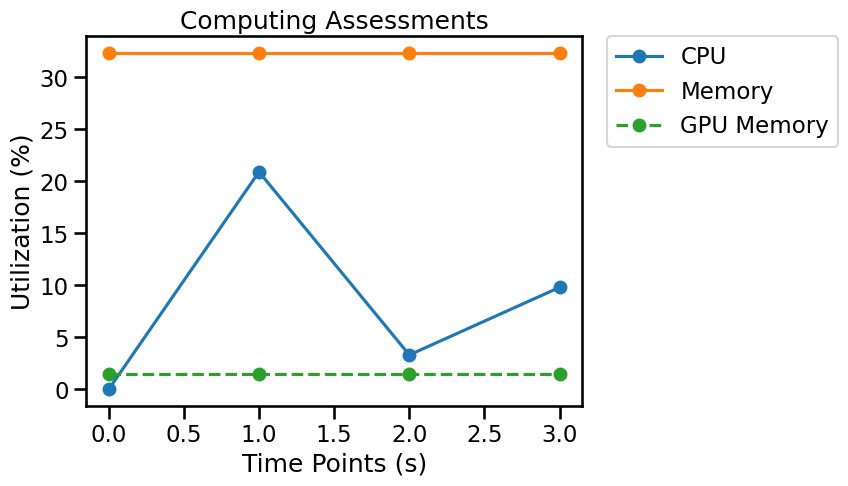

{'sys_info': {'CPU': 'x86_64 16-core @ 1.35 GHz',
  'RAM': '125.79 GB',
  'GPU': ['Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB']},
 'CPU': [0.0, 20.9, 3.3, 9.8],
 'Memory': [32.3, 32.3, 32.3, 32.3],
 'GPU': [0, 0, 0, 0],
 'GPU Memory': [1.46, 1.46, 1.46, 1.46],
 'time_points': [1758649508.869517,
  1758649510.0915756,
  1758649511.2356846,
  1758649512.4407055]}

In [3]:
monitor = Monitor(1)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
sc.tl.leiden(adata)
monitor.stop()

cluster_key: leiden

label_key: cell_ontology_class

embedding_key: X_umap

Clustering Scores:
Silhouette: 0.7259
NMI: 0.5057
ARI: 0.2741
Fowlkes Mallows: 0.5239


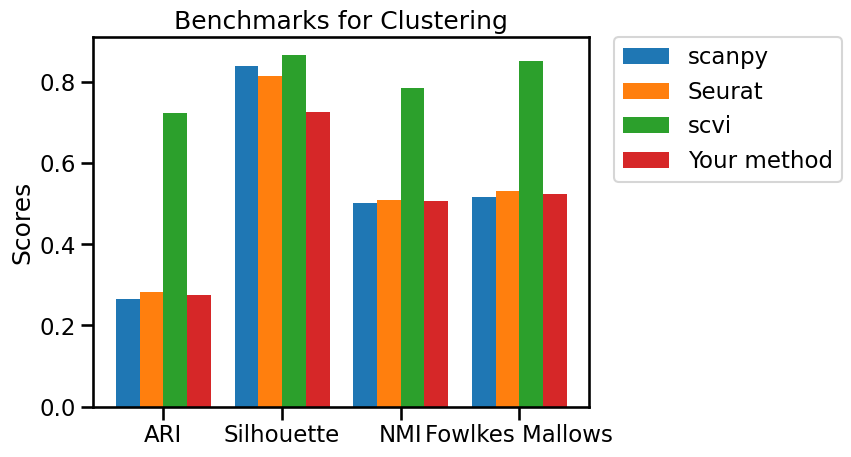

{'benchmarksId': 'CL-m-FACS_Bladder-1268-Tabula-2018',
 'datasetId': 'm-FACS_Bladder-1268-Tabula-2018',
 'task_type': 'Clustering',
 'tool': 'Your method',
 'Silhouette': 0.7259,
 'NMI': 0.5057,
 'ARI': 0.2741,
 'Fowlkes Mallows': 0.5239,
 'created_on': datetime.datetime(2025, 9, 23, 12, 45, 13, 926574)}

In [4]:
eval(adata, benchmarks_id="CL-m-FACS_Bladder-1268-Tabula-2018", cluster_key='leiden', embedding_key='X_umap')

In [5]:
eval(adata, benchmarks_id="CCC-m-10x_Brain-14249-Tasic-2016", ccc_pred="ccc_pred", score='score')

ccc_pred: ccc_pred

ccc_target: ccc_target

score: score

ccc_pred: ccc_pred

ccc_target: ccc_target

score: score



In [6]:
eval(adata, benchmarks_id="IM-h-10x_PBMC-1087-10x-2017", denoised_layer='denoised_layer')

denoised_layer: denoised_layer

denoised_layer: denoised_layer



In [7]:
eval(adata, benchmarks_id="CT-h-PBMC-10230-Adam-2022", label_pred_key='label_pred_key')

Failed to get Benchmarks: 'species'
label_pred_key: label_pred_key

label_key: labels

label_pred_key: label_pred_key

label_key: labels



In [8]:
eval(adata, adata, benchmarks_id="BI-h-PBMC-23589-Hao-2021", embedding_key='X_umap')

label_key: labels

batch_key: batch

label_key: labels

batch_key: batch



In [9]:
eval(adata, benchmarks_id="TJ-Planaria-Droplet_Planarian-18837-Mireya-2018", traj_key='traj_key')

traj_key: traj_key

bm_traj_key: benchmark_traj

root_node: origin_group

traj_key: traj_key

bm_traj_key: benchmark_traj

root_node: origin_group



In [10]:
eval(adata, benchmarks_id="MI-h-sci_CAR_Cell_Line-4739-Cao-2018", embedding_key='X_umap')

mod1_key: rna

label_key: cell_type

batch_key: group

embedding_key: X_umap

mod1_key: rna

label_key: cell_type

batch_key: group

embedding_key: X_umap

